# import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline

c:\Users\86157\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#  Data_weather

In [2]:
## read data
weather= pd.read_csv("data/weather_burbank_airport.csv")
weather.head(10)

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
5,Burbank,2018-01-01 13:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
6,Burbank,2018-01-01 14:53:00,7.0,30.0,Partly Cloudy,992.08,0.0,0.0,7.0
7,Burbank,2018-01-01 15:53:00,8.0,34.0,Fair,992.41,0.0,0.0,8.0
8,Burbank,2018-01-01 16:53:00,12.0,34.0,Fair,993.39,0.0,0.0,12.0
9,Burbank,2018-01-01 17:53:00,16.0,34.0,Fair,994.05,0.0,0.0,16.0


## check the weather dataset

In [3]:
weather.info()
### The columns of temperature,cloud_cover,cloud_cover_description,pressure, windspeed and felt_temperature have missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### fill in the missing values

In [4]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1,keys=['missing_number','missing_percent'])
    total_missing_number=missing_number.sum()
    total_missing_percent=missing_percent.sum()
    total_row=pd.DataFrame([[total_missing_number,total_missing_percent]],
                           columns=['missing_number','missing_percent'],
                           index=['total'])
    missing_values=pd.concat([missing_values,total_row])
    return missing_values
### Define a function to show the number and percentage of missing values for each column, as well as the total number of missing values in the entire dataset.

In [5]:
missing(weather)
### filter out columns like ‘City,’ ‘Precipitation,’ and ‘Timestamp’ (no null values)

,missing_number,missing_percent
windspeed,86,0.002941
felt_temperature,26,0.000889
temperature,25,0.000855
cloud_cover,20,0.000684
cloud_cover_description,20,0.000684
pressure,8,0.000274
city,0,0.000000
timestamp,0,0.000000
precipitation,0,0.000000
total,185,0.006326


In [6]:
weather_filling=weather.drop(['timestamp','city','precipitation','cloud_cover_description'], axis=1)
print(weather_filling)
### Delete columns with no missing values and non-numeric columns.

       temperature  cloud_cover  pressure  windspeed  felt_temperature
0              9.0         33.0    991.75        9.0               8.0
1              9.0         33.0    992.08        0.0               9.0
2              9.0         21.0    992.08        0.0               9.0
3              9.0         29.0    992.08        0.0               9.0
4              8.0         33.0    992.08        0.0               8.0
...            ...          ...       ...        ...               ...
29239         13.0         33.0    986.81        0.0              13.0
29240         12.0         33.0    986.81       11.0              12.0
29241         12.0         33.0    987.47        9.0              12.0
29242         11.0         33.0    987.14       13.0              11.0
29243         10.0         33.0    987.80        6.0              10.0

[29244 rows x 5 columns]


In [7]:
### Fill missing values with the mean values from the three rows above and below in the same column
for col in weather_filling.columns:
        if weather_filling[col].isnull().any():
            rolling_mean=weather_filling[col].rolling(window=7,min_periods=1,center=True).mean()
            weather_filling[col]=weather_filling[col].fillna(rolling_mean)
missing(weather_filling)

,missing_number,missing_percent
temperature,0,0.0
cloud_cover,0,0.0
pressure,0,0.0
windspeed,0,0.0
felt_temperature,0,0.0
total,0,0.0


In [8]:
### update original weather data
weather.update(weather_filling)
missing(weather)

,missing_number,missing_percent
cloud_cover_description,20,0.000684
city,0,0.000000
timestamp,0,0.000000
temperature,0,0.000000
cloud_cover,0,0.000000
pressure,0,0.000000
windspeed,0,0.000000
precipitation,0,0.000000
felt_temperature,0,0.000000
total,20,0.000684


In [9]:
### fill non-numeric columns(cloud_cover_description)
weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')
missing(weather)

C:\Users\86157\AppData\Local\Temp\ipykernel_20776\1945171366.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')


,missing_number,missing_percent
city,0,0.0
timestamp,0,0.0
temperature,0,0.0
cloud_cover,0,0.0
cloud_cover_description,0,0.0
pressure,0,0.0
windspeed,0,0.0
precipitation,0,0.0
felt_temperature,0,0.0
total,0,0.0


### Check for duplicates

In [10]:
weather.drop_duplicates
#### No duplicate data

<bound method DataFrame.drop_duplicates of           city            timestamp  temperature  cloud_cover  \
0      Burbank  2018-01-01 08:53:00          9.0         33.0   
1      Burbank  2018-01-01 09:53:00          9.0         33.0   
2      Burbank  2018-01-01 10:53:00          9.0         21.0   
3      Burbank  2018-01-01 11:53:00          9.0         29.0   
4      Burbank  2018-01-01 12:53:00          8.0         33.0   
...        ...                  ...          ...          ...   
29239  Burbank  2021-01-01 03:53:00         13.0         33.0   
29240  Burbank  2021-01-01 04:53:00         12.0         33.0   
29241  Burbank  2021-01-01 05:53:00         12.0         33.0   
29242  Burbank  2021-01-01 06:53:00         11.0         33.0   
29243  Burbank  2021-01-01 07:53:00         10.0         33.0   

      cloud_cover_description  pressure  windspeed  precipitation  \
0                        Fair    991.75        9.0            0.0   
1                        Fair    992.0

### Check for outlier

In [11]:
weather.describe()

,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature
count,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000
mean,17.883031,30.109382,986.879276,8.571036,0.059360,17.728579
std,6.453591,5.399077,3.606671,6.694556,0.471682,6.320396
min,2.000000,4.000000,971.000000,0.000000,0.000000,0.000000
25%,13.000000,26.000000,984.500000,6.000000,0.000000,13.000000
50%,17.000000,33.000000,986.480000,7.000000,0.000000,17.000000
75%,22.000000,34.000000,989.110000,13.000000,0.000000,22.000000
max,46.000000,47.000000,999.650000,57.000000,18.540000,42.000000


Value: 36.0, Count: 100
Value: 37.0, Count: 56
Value: 38.0, Count: 20
Value: 39.0, Count: 10
Value: 40.0, Count: 2
Value: 41.0, Count: 10
Value: 42.0, Count: 7
Value: 43.0, Count: 2
Value: 44.0, Count: 8
Value: 45.0, Count: 8
Value: 46.0, Count: 2


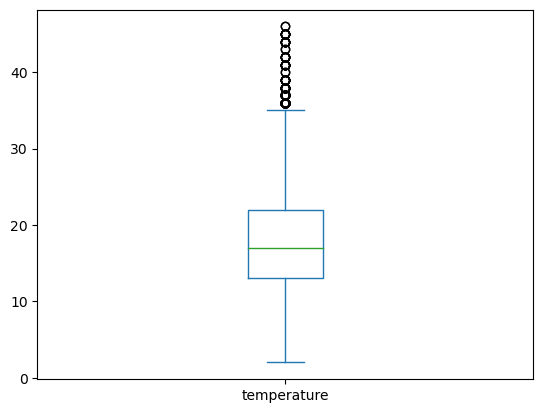

In [12]:
#### Generate a boxplot for the specified column, extract the outliers
#### and calculate the unique values of the outliers along with their frequencies.
plt.figure()
t=weather['temperature'].plot(kind='box',return_type='dict')
x=t['fliers'][0].get_xdata()
y=t['fliers'][0].get_ydata()
unique_values, counts = np.unique(y, return_counts=True)
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")


In [13]:
def plot_outliers(column):
    plt.figure()
    boxplot=weather[column].plot(kind='box',return_type='dict')
    x=boxplot['fliers'][0].get_xdata()
    y=boxplot['fliers'][0].get_ydata()
    unique_values, counts = np.unique(y, return_counts=True)
    for value, count in zip(unique_values, counts):
        print(f"Value: {value}, Count: {count}")
    plt.title(f"Boxplot of {column}")
    plt.show()

    

Value: 36.0, Count: 100
Value: 37.0, Count: 56
Value: 38.0, Count: 20
Value: 39.0, Count: 10
Value: 40.0, Count: 2
Value: 41.0, Count: 10
Value: 42.0, Count: 7
Value: 43.0, Count: 2
Value: 44.0, Count: 8
Value: 45.0, Count: 8
Value: 46.0, Count: 2


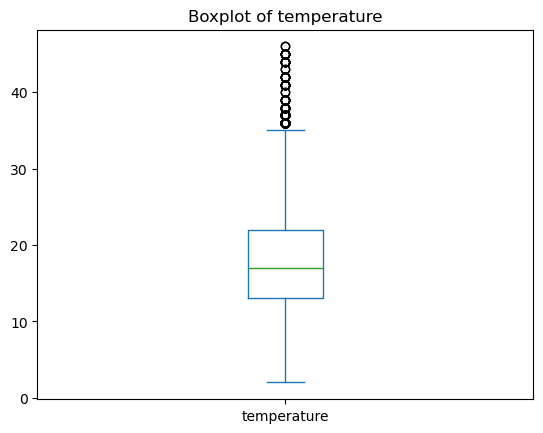

In [14]:
plot_outliers('temperature')

Value: 4.0, Count: 23
Value: 11.0, Count: 906
Value: 12.0, Count: 249
Value: 47.0, Count: 4


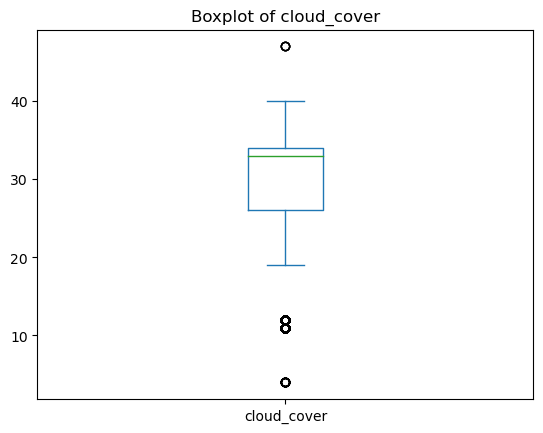

In [15]:
plot_outliers('cloud_cover')

Value: 971.0, Count: 2
Value: 971.33, Count: 2
Value: 971.66, Count: 4
Value: 971.99, Count: 2
Value: 972.32, Count: 3
Value: 972.65, Count: 3
Value: 972.98, Count: 1
Value: 973.31, Count: 13
Value: 973.64, Count: 11
Value: 973.97, Count: 11
Value: 974.3, Count: 10
Value: 974.63, Count: 12
Value: 974.95, Count: 10
Value: 975.28, Count: 12
Value: 975.61, Count: 19
Value: 975.94, Count: 9
Value: 976.27, Count: 14
Value: 976.6, Count: 11
Value: 976.93, Count: 18
Value: 977.26, Count: 7
Value: 996.03, Count: 60
Value: 996.36, Count: 56
Value: 996.69, Count: 47
Value: 997.02, Count: 34
Value: 997.34, Count: 17
Value: 997.67, Count: 21
Value: 998.0, Count: 18
Value: 998.33, Count: 15
Value: 998.66, Count: 10
Value: 998.99, Count: 5
Value: 999.32, Count: 2
Value: 999.65, Count: 5


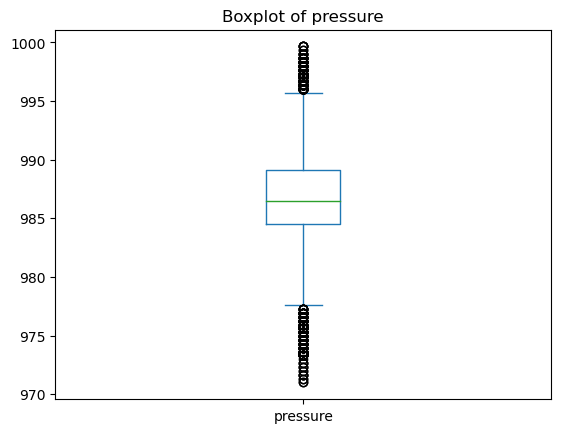

In [16]:
plot_outliers('pressure')

Value: 24.0, Count: 158
Value: 25.833333333333332, Count: 1
Value: 26.0, Count: 113
Value: 28.0, Count: 89
Value: 30.0, Count: 58
Value: 31.0, Count: 38
Value: 33.0, Count: 35
Value: 35.0, Count: 27
Value: 37.0, Count: 18
Value: 39.0, Count: 10
Value: 41.0, Count: 6
Value: 43.0, Count: 9
Value: 44.0, Count: 5
Value: 46.0, Count: 8
Value: 48.0, Count: 4
Value: 52.0, Count: 1
Value: 54.0, Count: 2
Value: 57.0, Count: 1


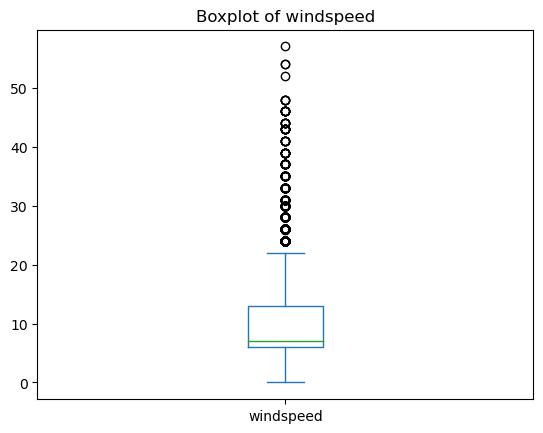

In [17]:
plot_outliers('windspeed')

Value: 0.25, Count: 313
Value: 0.51, Count: 158
Value: 0.76, Count: 125
Value: 1.02, Count: 86
Value: 1.27, Count: 80
Value: 1.52, Count: 59
Value: 1.78, Count: 50
Value: 2.03, Count: 31
Value: 2.29, Count: 32
Value: 2.54, Count: 33
Value: 2.79, Count: 23
Value: 3.05, Count: 11
Value: 3.3, Count: 20
Value: 3.56, Count: 12
Value: 3.81, Count: 7
Value: 4.06, Count: 6
Value: 4.32, Count: 15
Value: 4.57, Count: 9
Value: 4.83, Count: 9
Value: 5.08, Count: 13
Value: 5.33, Count: 8
Value: 5.59, Count: 4
Value: 5.84, Count: 4
Value: 6.1, Count: 4
Value: 6.35, Count: 2
Value: 6.6, Count: 2
Value: 6.86, Count: 6
Value: 7.11, Count: 1
Value: 7.37, Count: 3
Value: 7.62, Count: 3
Value: 7.87, Count: 2
Value: 8.13, Count: 2
Value: 8.38, Count: 1
Value: 8.64, Count: 2
Value: 9.91, Count: 3
Value: 10.67, Count: 1
Value: 10.92, Count: 1
Value: 11.18, Count: 1
Value: 11.43, Count: 1
Value: 12.45, Count: 1
Value: 12.7, Count: 1
Value: 13.97, Count: 1
Value: 18.54, Count: 1


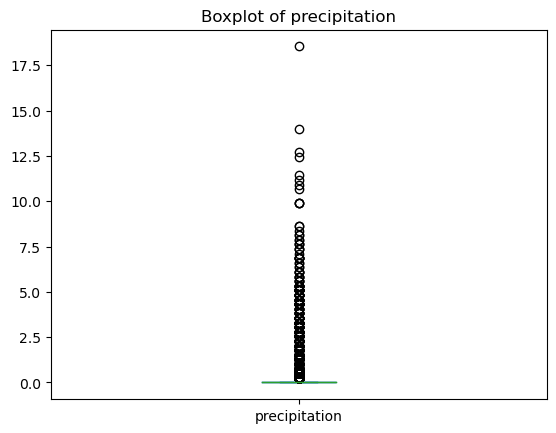

In [18]:
plot_outliers('precipitation')

Value: 36.0, Count: 38
Value: 37.0, Count: 21
Value: 38.0, Count: 13
Value: 39.0, Count: 11
Value: 40.0, Count: 6
Value: 41.0, Count: 13
Value: 42.0, Count: 6


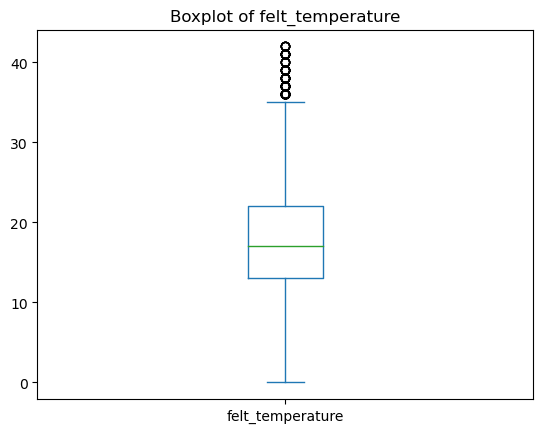

In [19]:
plot_outliers('felt_temperature')

##### I’m not sure how I should handle the outliers. We can discuss this during the group meeting

### Remove unnecessary columns from the DataFrame

In [20]:
weather['city'].unique()
# Since there is only one city, Burbank, which is located in Los Angeles, it is not meaningful for further modeling, so we will drop this column.

array(['Burbank'], dtype=object)

In [21]:
weather = weather.drop(columns=['city'])

In [22]:
# check the data type of each column
weather.dtypes

timestamp                   object
temperature                float64
cloud_cover                float64
cloud_cover_description     object
pressure                   float64
windspeed                  float64
precipitation              float64
felt_temperature           float64
dtype: object

In [23]:
# convert a timestamp format
weather['timestamp'] = pd.to_datetime(weather['timestamp'])

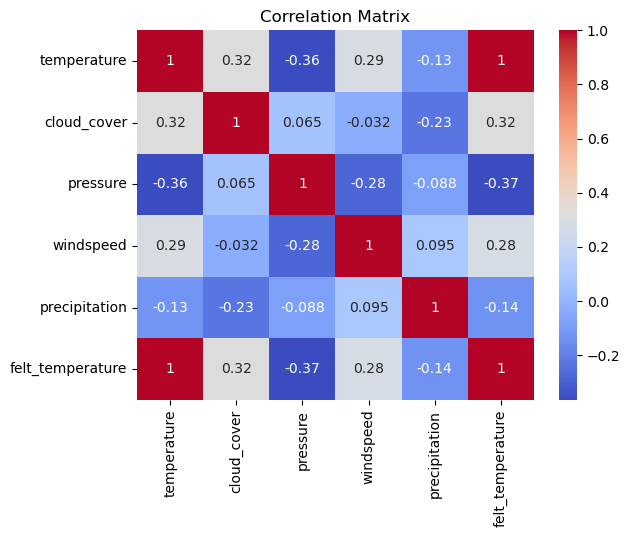

In [24]:
#check for correlation
numeric_columns = weather.select_dtypes(include=['float64'])
correlation_matrix = numeric_columns .corr()
# heatmap for correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [25]:
#Temperature and felt temperature are highly correlated, so we will drop the felt temperature column
weather = weather.drop(columns=['felt_temperature'])

In [26]:
weather.head()

,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
0,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0
1,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0
2,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0
3,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0
4,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0


# add the data to the weather dataset

In [27]:
charging=pd.read_csv("data/charging_sessions.csv")

In [28]:
weather['timestamp'].describe()
#the data start form 2018-01-01 08:53:00 to 2021-01-01 07:53:00

count                            29244
mean     2019-06-29 23:51:42.252770048
min                2018-01-01 08:53:00
25%                2018-10-06 05:38:00
50%                2019-06-24 00:23:00
75%                2020-03-25 20:08:00
max                2021-01-01 07:53:00
Name: timestamp, dtype: object

In [29]:
# convert a timestamp format
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.set_index('timestamp', inplace=True)

In [30]:
charging.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [31]:
charging['connectionTime'] = pd.to_datetime(charging['connectionTime'])

In [32]:
charging['connectionTime'].describe()
#the data start form 2018-04-25 11:08:04+00:00 to 2021-09-14 05:43:39+00:00
#There is missing weather data from January 1, 2021, 7:53 AM to September 14, 2021, 5:43:39 AM. 

count                                  66450
mean     2019-08-06 20:19:01.997832704+00:00
min                2018-04-25 11:08:04+00:00
25%         2018-11-13 08:28:56.500000+00:00
50%         2019-06-14 14:17:45.500000+00:00
75%         2020-01-08 00:31:54.500000+00:00
max                2021-09-14 05:43:39+00:00
Name: connectionTime, dtype: object

In [33]:
start_date = '2020-01-01 07:53:05'
end_date = '2020-09-14 05:43:39'
reference_time=weather.loc[start_date:end_date]
reference_time.index=reference_time.index+pd.DateOffset(years=1)
reference_time.head(25)

,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
timestamp,,,,,,
2021-01-01 08:53:00,9.0,33.0,Fair,989.77,11.0,0.0
2021-01-01 09:53:00,11.0,33.0,Fair,990.10,6.0,0.0
2021-01-01 10:53:00,9.0,29.0,Partly Cloudy,990.10,0.0,0.0
2021-01-01 11:53:00,8.0,29.0,Partly Cloudy,989.11,0.0,0.0
2021-01-01 12:53:00,7.0,29.0,Partly Cloudy,989.77,0.0,0.0
2021-01-01 13:53:00,7.0,33.0,Fair,989.44,0.0,0.0
2021-01-01 14:53:00,7.0,34.0,Fair,989.44,6.0,0.0
2021-01-01 15:53:00,8.0,34.0,Fair,989.77,7.0,0.0
2021-01-01 16:53:00,12.0,30.0,Partly Cloudy,990.76,9.0,0.0


In [34]:
weather_full=pd.concat([weather,reference_time])
weather_full.index

DatetimeIndex(['2018-01-01 08:53:00', '2018-01-01 09:53:00',
               '2018-01-01 10:53:00', '2018-01-01 11:53:00',
               '2018-01-01 12:53:00', '2018-01-01 13:53:00',
               '2018-01-01 14:53:00', '2018-01-01 15:53:00',
               '2018-01-01 16:53:00', '2018-01-01 17:53:00',
               ...
               '2021-09-13 20:02:00', '2021-09-13 20:53:00',
               '2021-09-13 21:53:00', '2021-09-13 22:53:00',
               '2021-09-13 23:53:00', '2021-09-14 00:53:00',
               '2021-09-14 01:53:00', '2021-09-14 02:53:00',
               '2021-09-14 03:53:00', '2021-09-14 04:53:00'],
              dtype='datetime64[ns]', name='timestamp', length=36070, freq=None)

In [35]:
missing(weather_full)

,missing_number,missing_percent
temperature,0,0.0
cloud_cover,0,0.0
cloud_cover_description,0,0.0
pressure,0,0.0
windspeed,0,0.0
precipitation,0,0.0
total,0,0.0


## Data charging_sessions

### Find duplicate values

In [36]:
new_df=charging.copy()
duplicates = new_df[new_df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Unnamed: 0, id, connectionTime, disconnectTime, doneChargingTime, kWhDelivered, sessionID, siteID, spaceID, stationID, timezone, userID, userInputs]
Index: []


### Add columns for charging time, connection time and idle time. 

In [37]:
new_df['disconnectTime'] = pd.to_datetime(new_df['disconnectTime']).dt.tz_localize(None)
new_df['connectionTime'] = pd.to_datetime(new_df['connectionTime']).dt.tz_localize(None)
new_df['doneChargingTime']=pd.to_datetime(new_df['doneChargingTime']).dt.tz_localize(None)
new_df['Connection_Time'] = new_df['disconnectTime'] - new_df['connectionTime']
new_df['Charging_Time']=new_df['doneChargingTime']-new_df['connectionTime']
new_df['Idle_Time']=new_df['Connection_Time']-new_df['Charging_Time']
print(new_df.head())

   Unnamed: 0                        id      connectionTime  \
0           0  5e23b149f9af8b5fe4b973cf 2020-01-02 13:08:54   
1           1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
2           2  5e23b149f9af8b5fe4b973d1 2020-01-02 13:56:35   
3           3  5e23b149f9af8b5fe4b973d2 2020-01-02 13:59:58   
4           4  5e23b149f9af8b5fe4b973d3 2020-01-02 14:00:01   

       disconnectTime    doneChargingTime  kWhDelivered  \
0 2020-01-02 19:11:15 2020-01-02 17:31:35        25.016   
1 2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
2 2020-01-03 00:39:22 2020-01-02 16:35:06         6.521   
3 2020-01-02 16:38:39 2020-01-02 15:18:45         2.355   
4 2020-01-02 22:08:40 2020-01-02 18:17:30        13.375   

                                sessionID  siteID  spaceID    stationID  \
0  1_1_179_810_2020-01-02 13:08:53.870034       1  AG-3F30  1-1-179-810   
1  1_1_193_825_2020-01-02 13:36:49.599853       1  AG-1F01  1-1-193-825   
2  1_1_193_829_2020-01-02 13:56:35.214993

In [38]:
new_df['Connection_Time_minutes'] = new_df['Connection_Time'].dt.total_seconds() / 60
new_df['Charging_Time_minutes'] = new_df['Charging_Time'].dt.total_seconds() / 60
new_df['Idle_Time_minutes'] = new_df['Idle_Time'].dt.total_seconds() / 60
print(new_df[['Charging_Time','Connection_Time','Idle_Time','Connection_Time_minutes','Charging_Time_minutes','Idle_Time_minutes']])

        Charging_Time Connection_Time         Idle_Time  \
0     0 days 04:22:41 0 days 06:02:21   0 days 01:39:40   
1     0 days 06:41:15 0 days 09:01:31   0 days 02:20:16   
2     0 days 02:38:31 0 days 10:42:47   0 days 08:04:16   
3     0 days 01:18:47 0 days 02:38:41   0 days 01:19:54   
4     0 days 04:17:29 0 days 08:08:39   0 days 03:51:10   
...               ...             ...               ...   
66445 0 days 05:22:14 0 days 05:21:14 -1 days +23:59:00   
66446 0 days 03:03:42 0 days 06:19:01   0 days 03:15:19   
66447 0 days 03:40:41 0 days 03:39:42 -1 days +23:59:01   
66448 0 days 02:05:43 0 days 05:15:04   0 days 03:09:21   
66449 0 days 01:29:47 0 days 02:38:17   0 days 01:08:30   

       Connection_Time_minutes  Charging_Time_minutes  Idle_Time_minutes  
0                   362.350000             262.683333          99.666667  
1                   541.516667             401.250000         140.266667  
2                   642.783333             158.516667         484.

In [39]:
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66450 non-null  int64          
 1   id                       66450 non-null  object         
 2   connectionTime           66450 non-null  datetime64[ns] 
 3   disconnectTime           66450 non-null  datetime64[ns] 
 4   doneChargingTime         62362 non-null  datetime64[ns] 
 5   kWhDelivered             66450 non-null  float64        
 6   sessionID                66450 non-null  object         
 7   siteID                   66450 non-null  int64          
 8   spaceID                  66450 non-null  object         
 9   stationID                66450 non-null  object         
 10  timezone                 66450 non-null  object         
 11  userID                   49187 non-null  float64        
 12  userInputs        

### Analyse Charging Time
#### From the table below, it is evident that some Charging Time and Idle Time values are negative, indicating data errors. 

In [40]:
print("\nStatisitcal Summary:")
print(new_df.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count  66450.000000                          66450   
mean    4726.102062  2019-08-06 20:19:01.997832704   
min        0.000000            2018-04-25 11:08:04   
25%     1845.000000     2018-11-13 08:28:56.500000   
50%     3960.000000     2019-06-14 14:17:45.500000   
75%     7027.000000     2020-01-08 00:31:54.500000   
max    15291.000000            2021-09-14 05:43:39   
std     3568.025394                            NaN   

                      disconnectTime               doneChargingTime  \
count                          66450                          62362   
mean   2019-08-07 02:36:36.576042240  2019-07-26 00:28:10.348946432   
min              2018-04-25 13:20:10            2018-04-25 13:21:10   
25%              2018-11-13 19:00:42  2018-11-15 10:24:38.249999872   
50%              2019-06-14 22:00:46            2019-06-05 20:53:37   
75%              2020-01-08 03:36:08  2019-12-17 18:40:35.2499998

#### There are 27 rows where doneChargingTime is earlier than connectionTime.

In [41]:
print(new_df[new_df['Charging_Time_minutes'] < 0])

       Unnamed: 0                        id      connectionTime  \
22219        2040  5c942ca4f9af8b06b04b3bb4 2019-03-05 19:13:55   
22253        2074  5c957e1cf9af8b42f440af03 2019-03-06 20:26:30   
23562        3383  5cca3a22f9af8b49aaa4cba0 2019-04-15 20:24:13   
23586        3407  5ccb8ba6f9af8b4d9721df00 2019-04-16 16:11:08   
27689        7510  5d856f1ff9af8b0c7bdf245c 2019-09-04 16:35:04   
27740        7561  5d86c0a5f9af8b1022a81870 2019-09-05 18:44:57   
29295        9116  5dcdffbdf9af8b220a19be8b 2019-10-29 17:22:32   
31285         492  5bc91740f9af8b0dc677b860 2018-05-04 19:08:37   
31287         494  5bc91740f9af8b0dc677b862 2018-05-04 19:23:52   
31403         610  5bc917d0f9af8b0dc677b8d6 2018-05-07 20:47:51   
35840        5047  5bc92c03f9af8b0dc677ca2b 2018-07-19 15:57:19   
38884        8091  5bc937f6f9af8b0dc677d60f 2018-08-29 05:25:08   
39875        9082  5bc93c1cf9af8b0dc677d9ee 2018-09-11 15:15:01   
41263       10470  5bc94185f9af8b0dc677df5a 2018-09-27 22:58:4

#### There are 4692 rows where disconnectTime is earlier than doneChargingTime.

In [42]:
print(new_df[new_df['Idle_Time_minutes'] < 0])

       Unnamed: 0                        id      connectionTime  \
12             12  5e23b149f9af8b5fe4b973db 2020-01-02 15:04:38   
20             20  5e23b149f9af8b5fe4b973e3 2020-01-02 15:28:47   
25             25  5e23b149f9af8b5fe4b973e8 2020-01-02 15:42:05   
26             26  5e23b149f9af8b5fe4b973e9 2020-01-02 15:57:24   
33             33  5e23b149f9af8b5fe4b973f0 2020-01-02 16:34:35   
...           ...                       ...                 ...   
66432       10070  5d574ad2f9af8b4c10c03645 2019-07-31 14:36:02   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   
66447       10085  5d574ad2f9af8b4c10c03654 2019-07-31 19:04:40   

           disconnectTime    doneChargingTime  kWhDelivered  \
12    2020-01-02 22:08:39 2020-01-02 22:09:36        25.567   
20    2020-01-02 19:01:54 2020-01-02 19:02:51         7.417   
25    

#### According to business logic, doneChargingTime cannot be earlier than connectionTime. Therefore, we delete 27 rows where doneChargingTime is earlier than connectionTime.

In [43]:
new_df = new_df.drop(new_df[new_df['Charging_Time_minutes'] < 0].index)
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         62335 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   49181 non-null  float64        
 12  userInputs             

### Filling null values(doneChargingTime)

In [44]:
print(new_df.describe())

         Unnamed: 0                 connectionTime  \
count  66423.000000                          66423   
mean    4724.823510  2019-08-06 22:33:04.837872128   
min        0.000000            2018-04-25 11:08:04   
25%     1845.000000     2018-11-13 14:23:23.500000   
50%     3959.000000            2019-06-14 14:33:06   
75%     7025.000000            2020-01-08 03:38:57   
max    15291.000000            2021-09-14 05:43:39   
std     3567.026437                            NaN   

                      disconnectTime               doneChargingTime  \
count                          66423                          62335   
mean   2019-08-07 04:50:35.555425280  2019-07-26 02:43:38.167642368   
min              2018-04-25 13:20:10            2018-04-25 13:21:10   
25%              2018-11-13 21:18:27            2018-11-15 17:18:23   
50%              2019-06-14 22:45:07            2019-06-05 21:40:58   
75%              2020-01-08 06:05:22            2019-12-17 18:57:21   
max             

From the table, it can be observed that the Charging_Time_minutes column contains significant outliers. To avoid the influence of these extreme values, we choose to fill the missing values with the median.

In [45]:
charging_time_median = new_df['Charging_Time_minutes'].median()
new_df['Charging_Time_minutes'] = new_df['Charging_Time_minutes'].fillna(value=charging_time_median)
new_df['doneChargingTime'] = new_df['doneChargingTime'].fillna(value=new_df['connectionTime'] + pd.to_timedelta(new_df['Charging_Time_minutes'], unit='m'))
new_df['Idle_Time_minutes']=new_df['Idle_Time_minutes'].fillna(value=new_df['Connection_Time_minutes']-new_df['Charging_Time_minutes'])
new_df['Charging_Time']=new_df['Charging_Time'].fillna(value=new_df['doneChargingTime']-new_df['connectionTime'])
new_df['Idle_Time']=new_df['Idle_Time'].fillna(new_df['Connection_Time']-new_df['Charging_Time'])
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   49181 non-null  float64        
 12  userInputs             

### Filling null values(userID and userInputs)

In [46]:
new_df['userID'] = new_df['userID'].fillna(value=-1)
new_df['userInputs'] = new_df['userInputs'].fillna(value='unknown')
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   66423 non-null  float64        
 12  userInputs             

### Finding outliers in the Charging_Time_minutes column

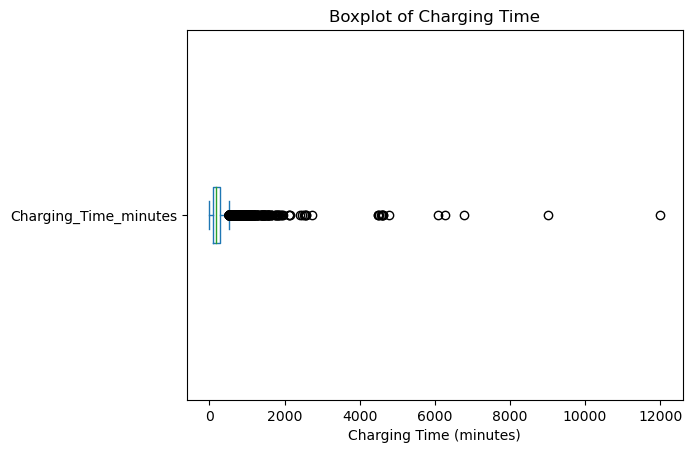

In [47]:
new_df['Charging_Time_minutes'].plot(kind='box', vert=False)
plt.title('Boxplot of Charging Time')
plt.xlabel('Charging Time (minutes)')
plt.show()

In [48]:
Q1 = new_df['Charging_Time_minutes'].quantile(0.25)
Q3 = new_df['Charging_Time_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = new_df[(new_df['Charging_Time_minutes'] < lower_bound)|(new_df['Charging_Time_minutes'] > upper_bound)]
print(outliers)

       Unnamed: 0                        id      connectionTime  \
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
29             29  5e23b149f9af8b5fe4b973ec 2020-01-02 16:28:23   
81             81  5e28f766f9af8b70ebc91c98 2020-01-06 12:32:26   
83             83  5e28f766f9af8b70ebc91c9a 2020-01-06 12:48:56   
89             89  5e28f766f9af8b70ebc91ca0 2020-01-06 13:53:44   
...           ...                       ...                 ...   
66420       10058  5d574ad2f9af8b4c10c03639 2019-07-31 14:04:17   
66421       10059  5d574ad2f9af8b4c10c0363a 2019-07-31 14:05:20   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66442       10080  5d574ad2f9af8b4c10c0364f 2019-07-31 14:48:11   

           disconnectTime    doneChargingTime  kWhDelivered  \
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
29    2020-01-03 03:10:07 2020-01-03 02:46:22        12.082   
81    

In [49]:
print("\nStatisitcal Summary:")
print(outliers.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count   3083.000000                           3083   
mean    4737.656828  2019-06-18 07:44:14.757703424   
min        6.000000            2018-04-26 13:54:17   
25%     1935.000000            2018-11-01 14:18:18   
50%     4067.000000            2019-06-06 13:50:01   
75%     6939.500000            2019-10-30 14:24:57   
max    15289.000000            2021-09-14 05:43:39   
std     3456.282688                            NaN   

                   disconnectTime               doneChargingTime  \
count                        3083                           3083   
mean   2019-06-18 19:44:08.252352  2019-06-18 18:40:50.476808192   
min           2018-04-26 23:08:24            2018-04-26 23:07:12   
25%    2018-11-02 00:02:30.500000            2018-11-01 23:51:16   
50%           2019-06-06 23:30:24            2019-06-06 23:06:09   
75%           2019-10-31 00:17:58     2019-10-31 00:07:59.500000   
max           2

### Finding outliers in the Connection_Time_minutes column

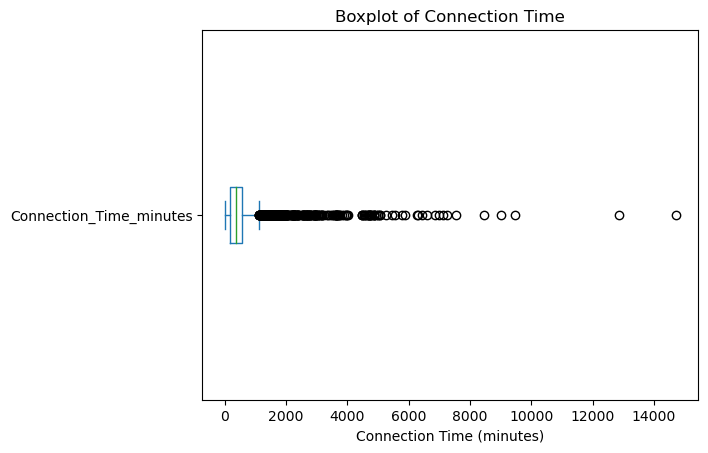

In [50]:
new_df['Connection_Time_minutes'].plot(kind='box', vert=False)
plt.title('Boxplot of Connection Time')
plt.xlabel('Connection Time (minutes)')
plt.show()

In [51]:
Q1_con = new_df['Connection_Time_minutes'].quantile(0.25)
Q3_con = new_df['Connection_Time_minutes'].quantile(0.75)
IQR_con = Q3_con - Q1_con
lower_bound_con = Q1_con - 1.5 * IQR_con
upper_bound_con = Q3_con + 1.5 * IQR_con
outliers_con = new_df[(new_df['Connection_Time_minutes'] < lower_bound_con)|(new_df['Connection_Time_minutes'] > upper_bound_con)]
print(outliers_con)

       Unnamed: 0                        id      connectionTime  \
7246         1673  5d5f33d2f9af8b650c8bfe56 2019-08-07 01:12:26   
7627         2054  5d69bfebf9af8b0682723ef7 2019-08-14 13:00:40   
7911         2338  5d71a8d8f9af8b435820d055 2019-08-20 14:20:30   
8960         3387  5d8d585ff9af8b2ac272ab86 2019-09-11 00:33:34   
11091        5518  5dc4c574f9af8b0159f31844 2019-10-22 23:35:50   
...           ...                       ...                 ...   
61169        4807  5cca3a54f9af8b49aaa4cbee 2019-04-16 00:01:28   
62402        6040  5ce88ce2f9af8b5b259d72f2 2019-05-09 00:09:47   
62651        6289  5cf075ecf9af8b74808d8308 2019-05-14 14:48:06   
63029        6667  5cf85ee3f9af8b11f3749cbe 2019-05-21 00:10:00   
64086        7724  5d16b161f9af8b7bdb8babc7 2019-06-12 13:38:35   

           disconnectTime    doneChargingTime  kWhDelivered  \
7246  2019-08-08 00:03:44 2019-08-07 10:11:52        57.217   
7627  2019-08-16 02:24:39 2019-08-14 14:48:08         4.557   
7911  

In [52]:
print("\nStatisitcal Summary:")
print(outliers_con.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count    467.000000                            467   
mean    5370.653105  2019-04-07 06:32:11.856530944   
min        4.000000            2018-04-25 18:22:03   
25%     2053.000000     2018-08-04 11:16:26.500000   
50%     4370.000000            2018-12-15 21:04:01   
75%     7978.000000     2019-08-08 08:28:25.500000   
max    15289.000000            2021-07-21 16:44:24   
std     3999.135694                            NaN   

                      disconnectTime               doneChargingTime  \
count                            467                            467   
mean   2019-04-08 19:11:27.796573696  2019-04-07 17:50:08.361884160   
min              2018-04-29 00:24:02            2018-04-26 01:41:10   
25%       2018-08-06 09:16:41.500000     2018-08-05 04:43:15.500000   
50%              2018-12-16 20:54:29            2018-12-15 23:13:00   
75%       2019-08-10 00:59:58.500000            2019-08-09 07:53:

### Finding outliers in the kWhDelivered column

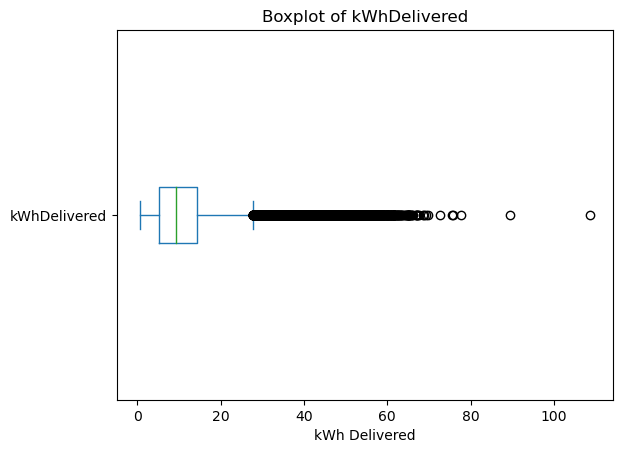

In [53]:
new_df['kWhDelivered'].plot(kind='box', vert=False)
plt.title('Boxplot of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.show()

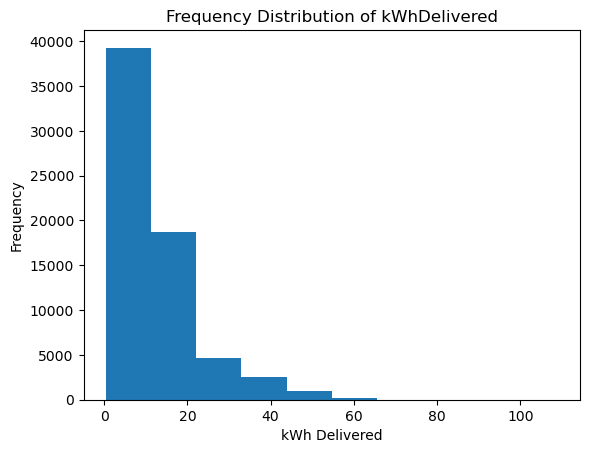

In [54]:
plt.hist(new_df['kWhDelivered'])
plt.title('Frequency Distribution of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.ylabel('Frequency')
plt.show()

In [55]:
Q1_kWh = new_df['kWhDelivered'].quantile(0.25)
Q3_kWh = new_df['kWhDelivered'].quantile(0.75)
IQR_kWh = Q3_kWh - Q1_kWh
lower_bound_kWh = Q1_kWh - 1.5 * IQR_kWh
upper_bound_kWh = Q3_kWh + 1.5 * IQR_kWh
outliers_kWh = new_df[(new_df['kWhDelivered'] < lower_bound_kWh)|(new_df['kWhDelivered'] > upper_bound_kWh)]
print(outliers_kWh)

       Unnamed: 0                        id      connectionTime  \
1               1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
7               7  5e23b149f9af8b5fe4b973d6 2020-01-02 14:17:32   
13             13  5e23b149f9af8b5fe4b973dc 2020-01-02 15:15:27   
21             21  5e23b149f9af8b5fe4b973e4 2020-01-02 15:30:19   
...           ...                       ...                 ...   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66428       10066  5d574ad2f9af8b4c10c03641 2019-07-31 14:30:47   
66433       10071  5d574ad2f9af8b4c10c03646 2019-07-31 14:38:24   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   

           disconnectTime    doneChargingTime  kWhDelivered  \
1     2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
7     

In [56]:
print("\nStatisitcal Summary:")
print(outliers_kWh.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count   5751.000000                           5751   
mean    4156.843679  2019-11-09 08:05:01.848721920   
min        0.000000            2018-04-25 16:25:51   
25%     1653.000000     2019-03-22 13:23:02.500000   
50%     3556.000000            2019-08-29 14:35:02   
75%     5936.000000            2020-02-27 18:54:45   
max    15289.000000            2021-09-14 05:43:39   
std     3145.383383                            NaN   

                      disconnectTime               doneChargingTime  \
count                           5751                           5751   
mean   2019-11-09 16:48:20.922796032  2019-11-09 15:03:19.655190528   
min              2018-04-25 22:30:46            2018-04-25 22:30:41   
25%       2019-03-22 19:58:29.500000     2019-03-22 19:58:20.500000   
50%              2019-08-30 00:23:23            2019-08-29 23:49:56   
75%       2020-02-28 02:55:08.500000            2020-02-28 02:00:

### Merge data using connectionTime as the key

In [57]:
print(weather_full.head())

                     temperature  cloud_cover cloud_cover_description  \
timestamp                                                               
2018-01-01 08:53:00          9.0         33.0                    Fair   
2018-01-01 09:53:00          9.0         33.0                    Fair   
2018-01-01 10:53:00          9.0         21.0                    Haze   
2018-01-01 11:53:00          9.0         29.0           Partly Cloudy   
2018-01-01 12:53:00          8.0         33.0                    Fair   

                     pressure  windspeed  precipitation  
timestamp                                                
2018-01-01 08:53:00    991.75        9.0            0.0  
2018-01-01 09:53:00    992.08        0.0            0.0  
2018-01-01 10:53:00    992.08        0.0            0.0  
2018-01-01 11:53:00    992.08        0.0            0.0  
2018-01-01 12:53:00    992.08        0.0            0.0  


In [58]:
print(weather_full.describe())

        temperature   cloud_cover      pressure     windspeed  precipitation
count  36070.000000  36070.000000  36070.000000  36070.000000   36070.000000
mean      17.994604     30.186862    986.849541      8.657353       0.056577
std        6.510286      5.377450      3.600140      6.686105       0.455689
min        2.000000      4.000000    971.000000      0.000000       0.000000
25%       13.000000     27.000000    984.500000      6.000000       0.000000
50%       17.000000     33.000000    986.480000      7.000000       0.000000
75%       22.000000     34.000000    989.110000     13.000000       0.000000
max       46.000000     47.000000    999.650000     57.000000      18.540000


In [59]:
print(weather_full.columns)

Index(['temperature', 'cloud_cover', 'cloud_cover_description', 'pressure',
       'windspeed', 'precipitation'],
      dtype='object')


In [60]:
weather_full=weather_full.reset_index()
print(weather_full.columns)

Index(['timestamp', 'temperature', 'cloud_cover', 'cloud_cover_description',
       'pressure', 'windspeed', 'precipitation'],
      dtype='object')


In [61]:
weather_full['timestamp'] = pd.to_datetime(weather_full['timestamp'])
def find_closest_weather(row):
    connection_time = row['connectionTime']
    time_diff = (weather_full['timestamp'] - connection_time).abs()
    closest_index = time_diff.idxmin()
    return weather_full.loc[closest_index]
closest_weather = new_df.apply(find_closest_weather, axis=1)
weather_columns = ['timestamp', 'temperature', 'cloud_cover', 'cloud_cover_description', 'pressure', 'windspeed', 'precipitation']
for col in weather_columns:
    new_df[col] = closest_weather[col].values

In [62]:
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   66423 non-null  float64        
 12  userInputs             

In [63]:
max_value_row = new_df[new_df['connectionTime'] == new_df['connectionTime'].max()]
print(max_value_row)

       Unnamed: 0                        id      connectionTime  \
20178        5875  6155053bf9af8b76960e16d1 2021-09-14 05:43:39   

           disconnectTime    doneChargingTime  kWhDelivered  \
20178 2021-09-14 14:46:28 2021-09-14 14:46:22        53.937   

                                    sessionID  siteID  spaceID    stationID  \
20178  1_1_178_817_2021-09-14 05:43:27.354300       1  AG-1F09  1-1-178-817   

       ... Connection_Time_minutes  Charging_Time_minutes Idle_Time_minutes  \
20178  ...              542.816667             542.716667               0.1   

                timestamp temperature cloud_cover  cloud_cover_description  \
20178 2021-09-14 04:53:00        22.0        33.0                     Fair   

       pressure  windspeed precipitation  
20178    985.16        9.0           0.0  

[1 rows x 26 columns]


In [64]:
new_df.to_csv('merged_data.csv')